<a href="https://colab.research.google.com/github/nicolasengland14-gif/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment%202/Econ_5200_Assignment_2_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [85]:
import numpy as np
normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)
latency_logs = np.concatenate([normal_traffic, spike_traffic])

In [86]:
def calculate_mad(data):
  x = np.array(data)
  median = np.median(x)
  abs_dev = np.abs(x - median)
  mod = np.median(abs_dev)
  return mod

sd = np.std(latency_logs, ddof=1)
mad = calculate_mad(latency_logs)

print("Standard Deviation:", sd)
print("MAD:", mad)

Standard Deviation: 472.85699838843976
MAD: 8.0


MAD remains stable because it uses the median, whereas the standard deviation uses the mean

In [87]:
sensitivity = 0.98
specificity = 0.98

def bayesian_audit(prior, sensitivity, specificity):
  cheat = prior
  no_cheat = 1 - prior
  true_positive = sensitivity * cheat
  false_positive = (1 - specificity) * no_cheat
  posterior = true_positive / (true_positive + false_positive)
  return posterior

In [88]:
# Scenario A (Bootcamp): Base Rate = 50%
scenario_a = bayesian_audit(.5, sensitivity, specificity)
# Scenario B (Econ Class): Base Rate = 5%
scenario_b = bayesian_audit(.05, sensitivity, specificity)
# Scenario C (Honors Seminar): Base Rate = 0.1%
scenario_c = bayesian_audit(.001, sensitivity, specificity)
print("Bootcamp:",scenario_a)
print("Econ Class:",scenario_b)
print("Honors Seminar:", scenario_c)

Bootcamp: 0.98
Econ Class: 0.7205882352941175
Honors Seminar: 0.04675572519083965


In [89]:
# Chi-Square Formula: Sum( (Observed - Expected)^2 / Expected )
observed = np.array([50250,49750])
expected = np.array([50000,50000])
# Write the calculation loop...

chi_square = np.sum((observed - expected)**2 / expected)

if chi_square > 3.84:
  print("Invalid due to engineering bias")
else:
  print("Valid")

print("Chi-Square:", chi_square)

Valid
Chi-Square: 2.5


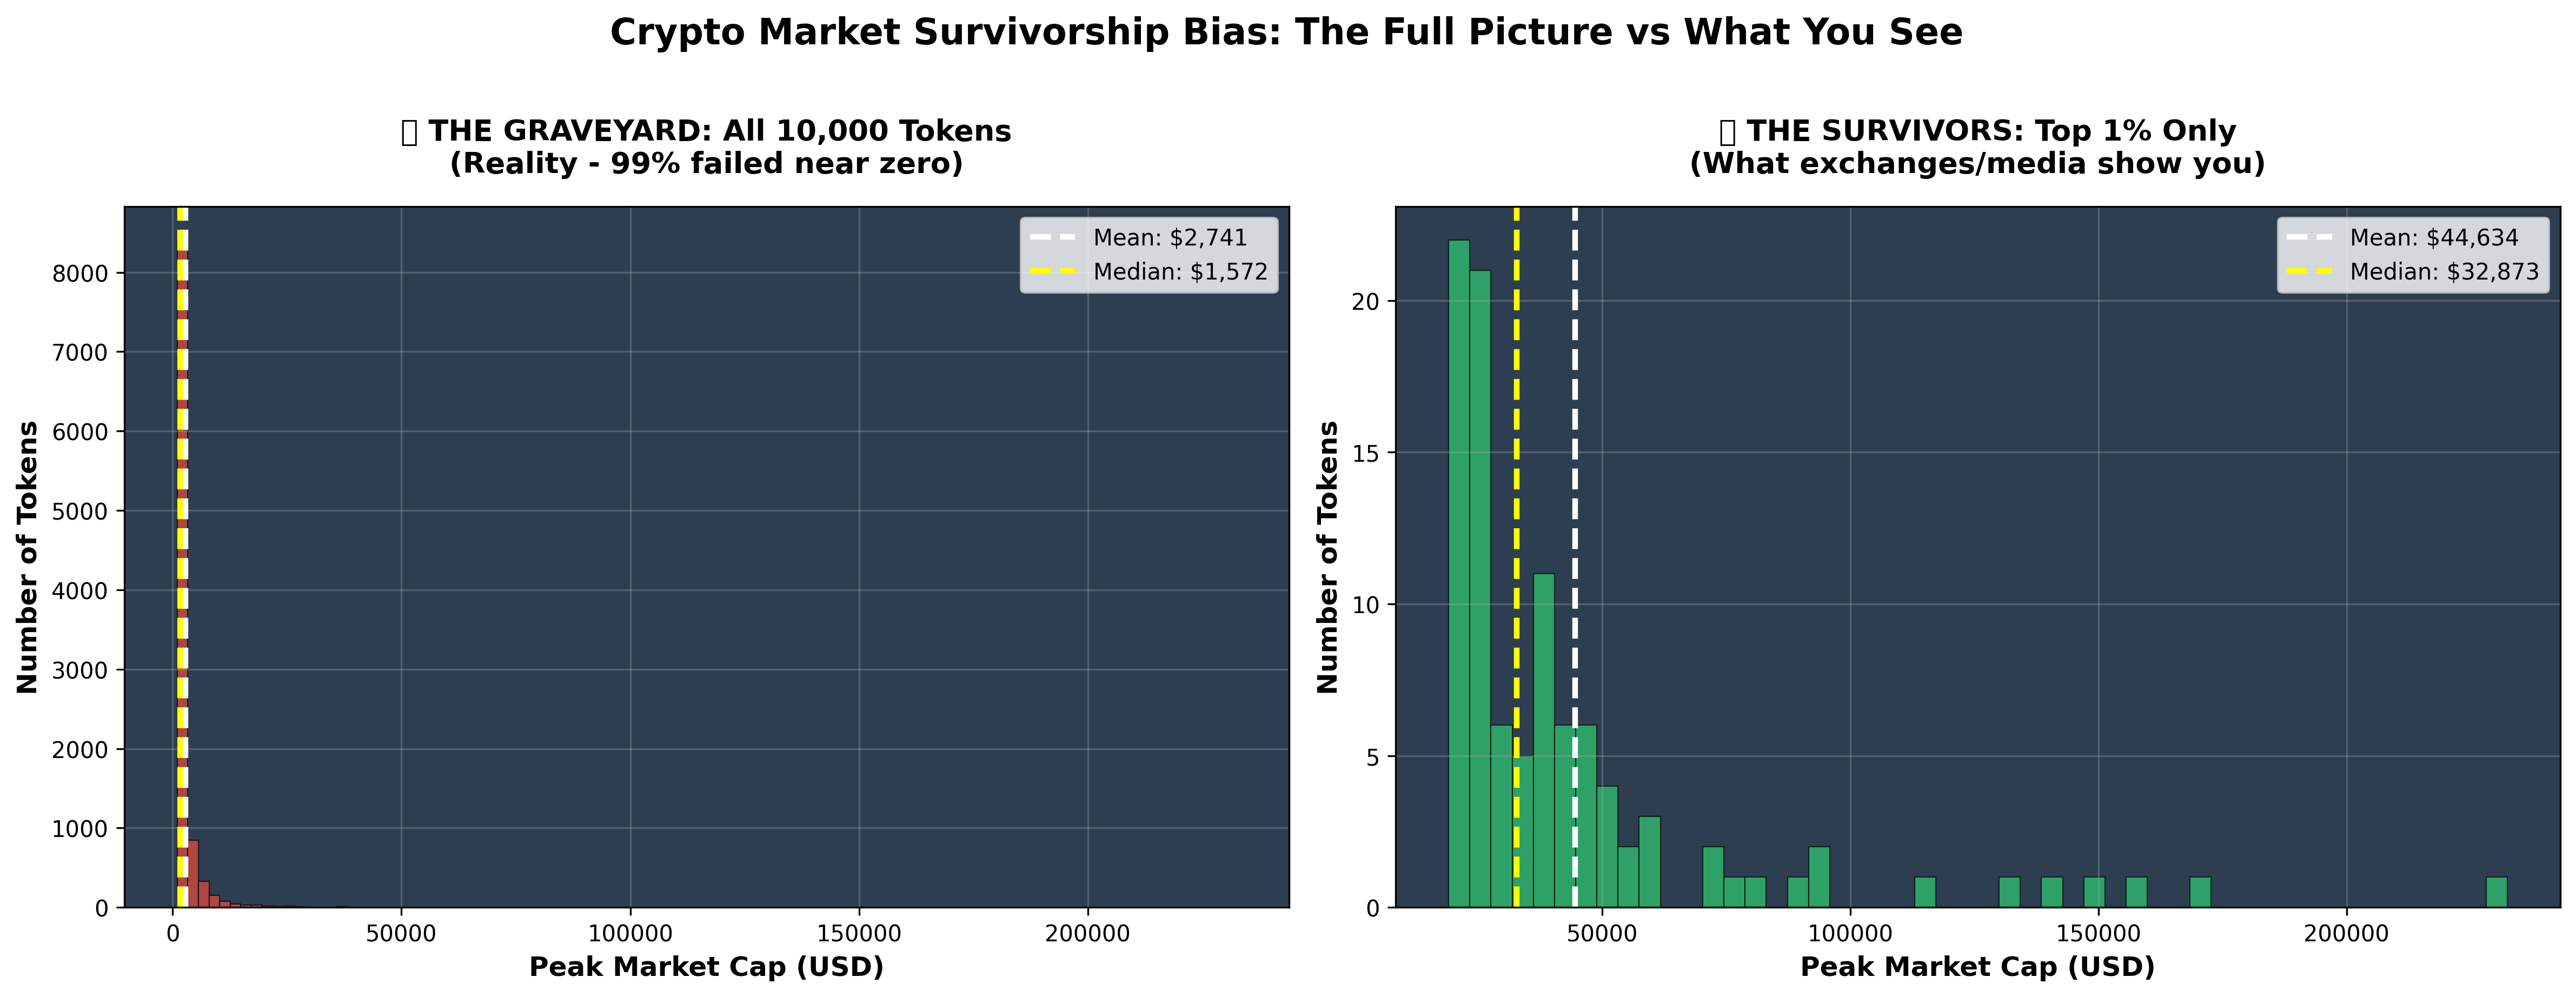

In [90]:
from IPython.display import Image
Image('crypto_survivorship_bias.png')